# Model Evaluation - Interactive Analysis

This notebook provides interactive exploration of trained ML models:
- Random Forest, XGBoost, LightGBM
- Comprehensive metrics and visualizations
- Model comparison and error analysis
- Threshold optimization

In [1]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))
from utils.metrics import (
    ClassificationMetrics,
    BusinessMetrics,
    ThresholdOptimizer,
    MetricsVisualizer
)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Imports successful!")

✅ Imports successful!


## 1. Load Evaluation Reports

In [2]:
# Load evaluation reports
REPORTS_DIR = Path.cwd().parent / "reports" / "evaluation"

reports = {}
for model in ["random_forest", "xgboost", "lightgbm"]:
    report_path = REPORTS_DIR / f"{model}_evaluation_report.json"
    if report_path.exists():
        with open(report_path, 'r') as f:
            reports[model] = json.load(f)
        print(f"✅ Loaded {model} report")
    else:
        print(f"⚠️ Report not found: {report_path}")

print(f"\nTotal reports loaded: {len(reports)}")

✅ Loaded random_forest report
✅ Loaded xgboost report
✅ Loaded lightgbm report

Total reports loaded: 3


## 2. Model Comparison Dashboard

In [3]:
# Create comparison dataframe
comparison_data = []
for model_name, report in reports.items():
    comparison_data.append({
        'Model': model_name,
        'F1-Score': report.get('f1_score', 0),
        'Precision': report.get('precision', 0),
        'Recall': report.get('recall', 0),
        'ROC-AUC': report.get('roc_auc', 0),
        'PR-AUC': report.get('pr_auc', 0),
        'MCC': report.get('mcc', 0),
        'Total Cost ($)': report.get('total_cost', 0)
    })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Model')

print("📊 MODEL COMPARISON")
print("=" * 80)
display(df_comparison.style.format({
    'F1-Score': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'PR-AUC': '{:.4f}',
    'MCC': '{:.4f}',
    'Total Cost ($)': '{:,.2f}'
}).background_gradient(cmap='RdYlGn', subset=['F1-Score', 'Precision', 'Recall', 'ROC-AUC', 'PR-AUC', 'MCC']))

📊 MODEL COMPARISON


,F1-Score,Precision,Recall,ROC-AUC,PR-AUC,MCC,Total Cost ($)
Model,,,,,,,
random_forest,0.7273,0.5714,1.0000,1.0000,0.9306,0.7559,30.00
xgboost,0.4211,0.2667,1.0000,1.0000,0.9276,0.5163,110.00
lightgbm,0.9412,0.8889,1.0000,1.0000,1.0000,0.9428,5.00


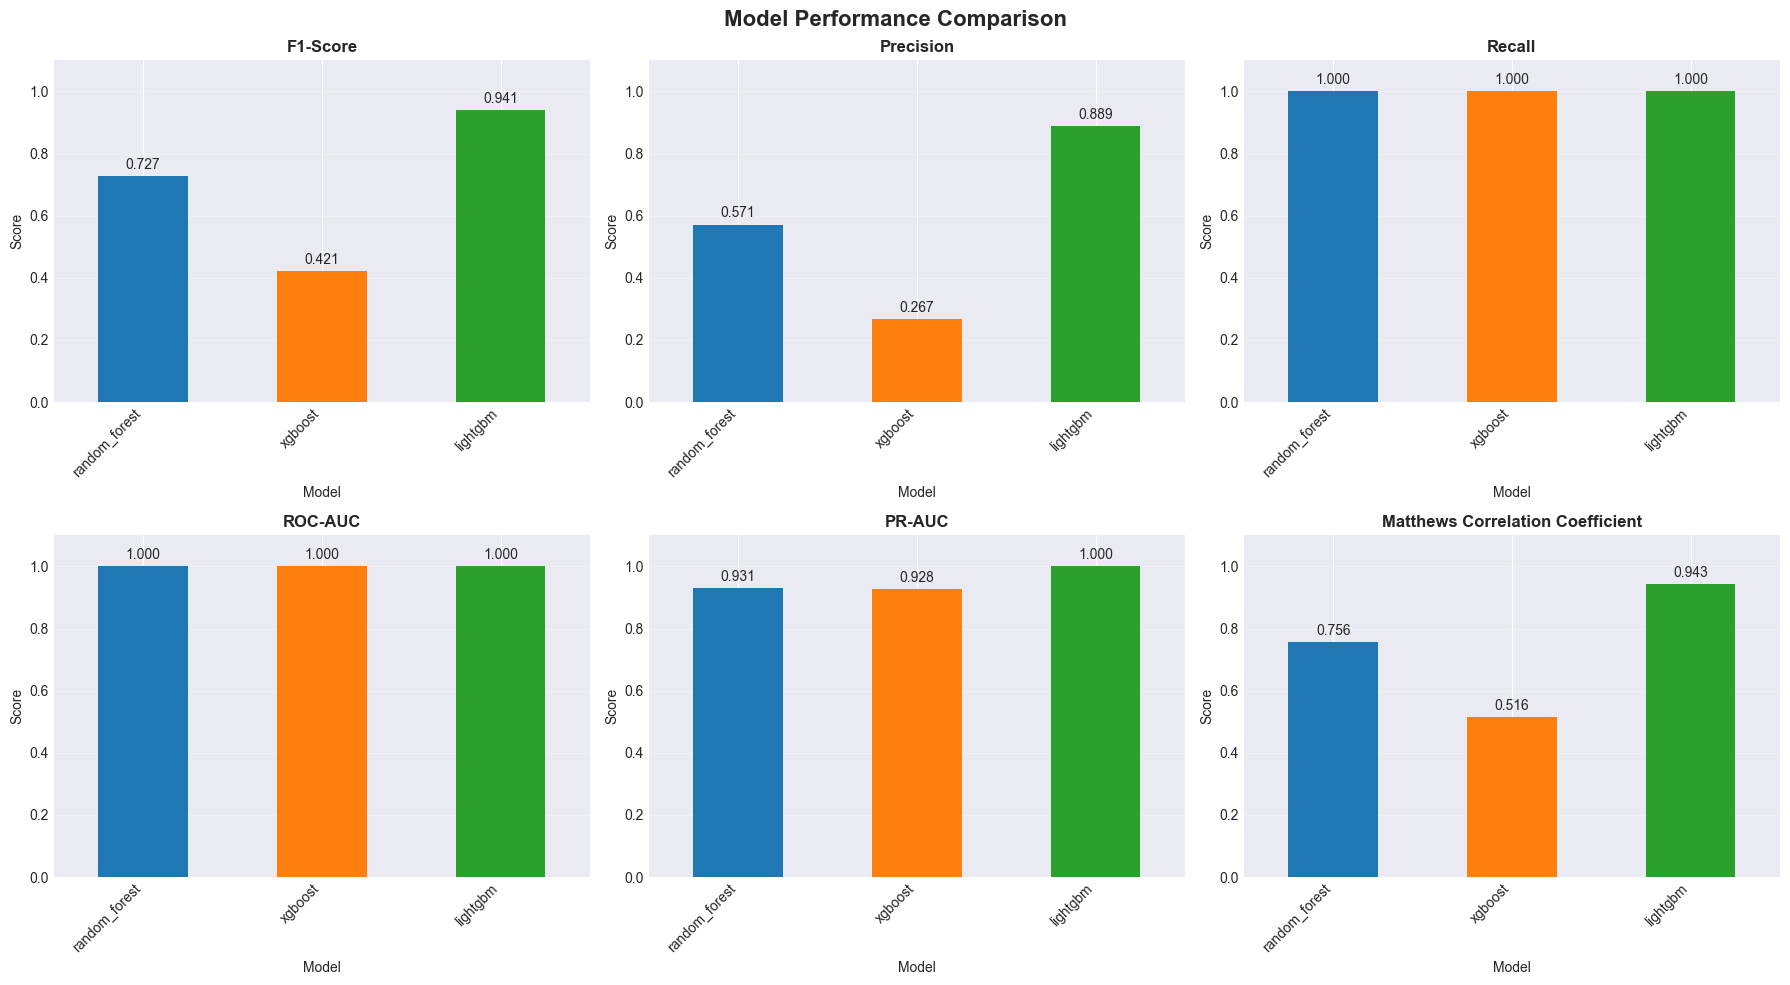

In [4]:
# Plot metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = [
    ('F1-Score', 'F1-Score'),
    ('Precision', 'Precision'),
    ('Recall', 'Recall'),
    ('ROC-AUC', 'ROC-AUC'),
    ('PR-AUC', 'PR-AUC'),
    ('MCC', 'Matthews Correlation Coefficient')
]

for idx, (metric_key, metric_name) in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    df_comparison[metric_key].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(metric_name, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

## 3. Confusion Matrix Analysis

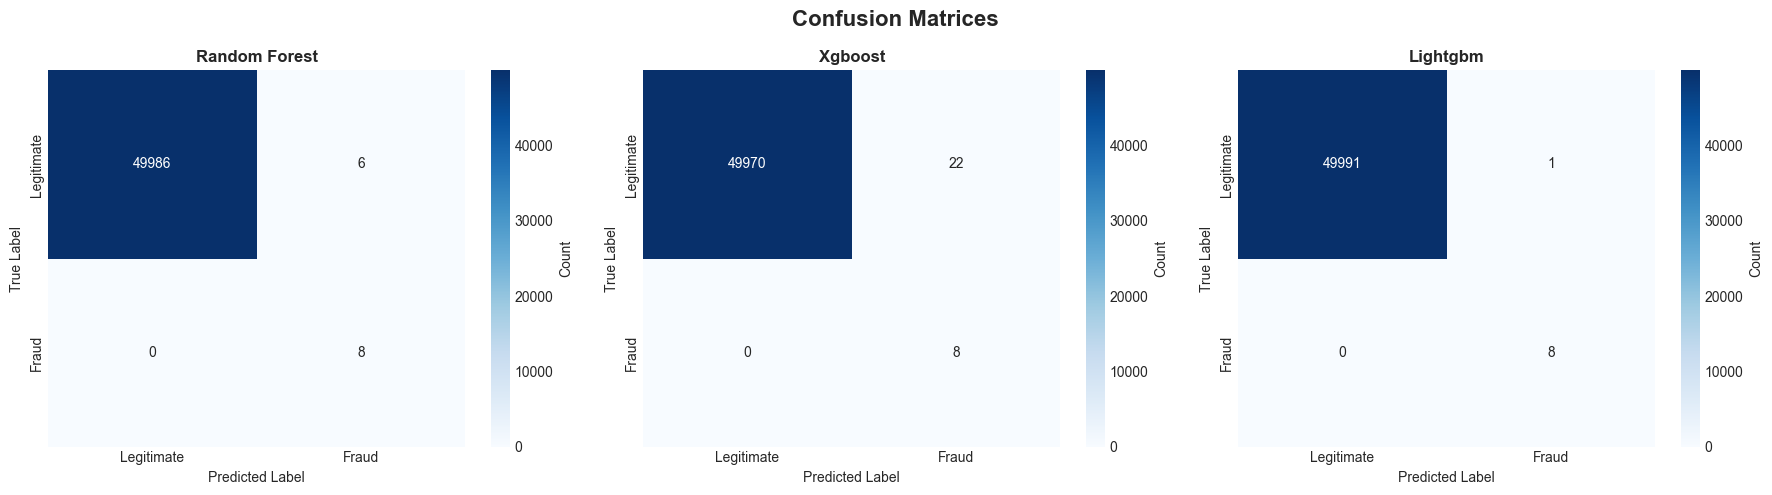

In [5]:
# Display confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for idx, (model_name, report) in enumerate(reports.items()):
    ax = axes[idx]
    
    # Extract confusion matrix
    tn = report.get('true_negatives', 0)
    fp = report.get('false_positives', 0)
    fn = report.get('false_negatives', 0)
    tp = report.get('true_positives', 0)
    
    cm = np.array([[tn, fp], [fn, tp]])
    
    # Plot
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud'],
        ax=ax, cbar_kws={'label': 'Count'}
    )
    ax.set_title(f'{model_name.replace("_", " ").title()}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 4. Business Metrics Analysis

In [6]:
# Business metrics comparison
business_data = []
for model_name, report in reports.items():
    business_data.append({
        'Model': model_name,
        'Total Cost ($)': report.get('total_cost', 0),
        'FP Cost ($)': report.get('total_fp_cost', 0),
        'FN Cost ($)': report.get('total_fn_cost', 0),
        'FPR': report.get('false_positive_rate', 0),
        'FNR': report.get('false_negative_rate', 0),
        'Precision @ 1%': report.get('precision_at_1pct', 0),
        'Precision @ 5%': report.get('precision_at_5pct', 0)
    })

df_business = pd.DataFrame(business_data).set_index('Model')

print("💰 BUSINESS METRICS")
print("=" * 80)
display(df_business.style.format({
    'Total Cost ($)': '{:,.2f}',
    'FP Cost ($)': '{:,.2f}',
    'FN Cost ($)': '{:,.2f}',
    'FPR': '{:.4f}',
    'FNR': '{:.4f}',
    'Precision @ 1%': '{:.4f}',
    'Precision @ 5%': '{:.4f}'
}))

💰 BUSINESS METRICS


,Total Cost ($),FP Cost ($),FN Cost ($),FPR,FNR,Precision @ 1%,Precision @ 5%
Model,,,,,,,
random_forest,30.00,30.00,0.00,0.0001,0.0000,0.0160,0.0032
xgboost,110.00,110.00,0.00,0.0004,0.0000,0.0160,0.0032
lightgbm,5.00,5.00,0.00,0.0000,0.0000,0.0160,0.0032


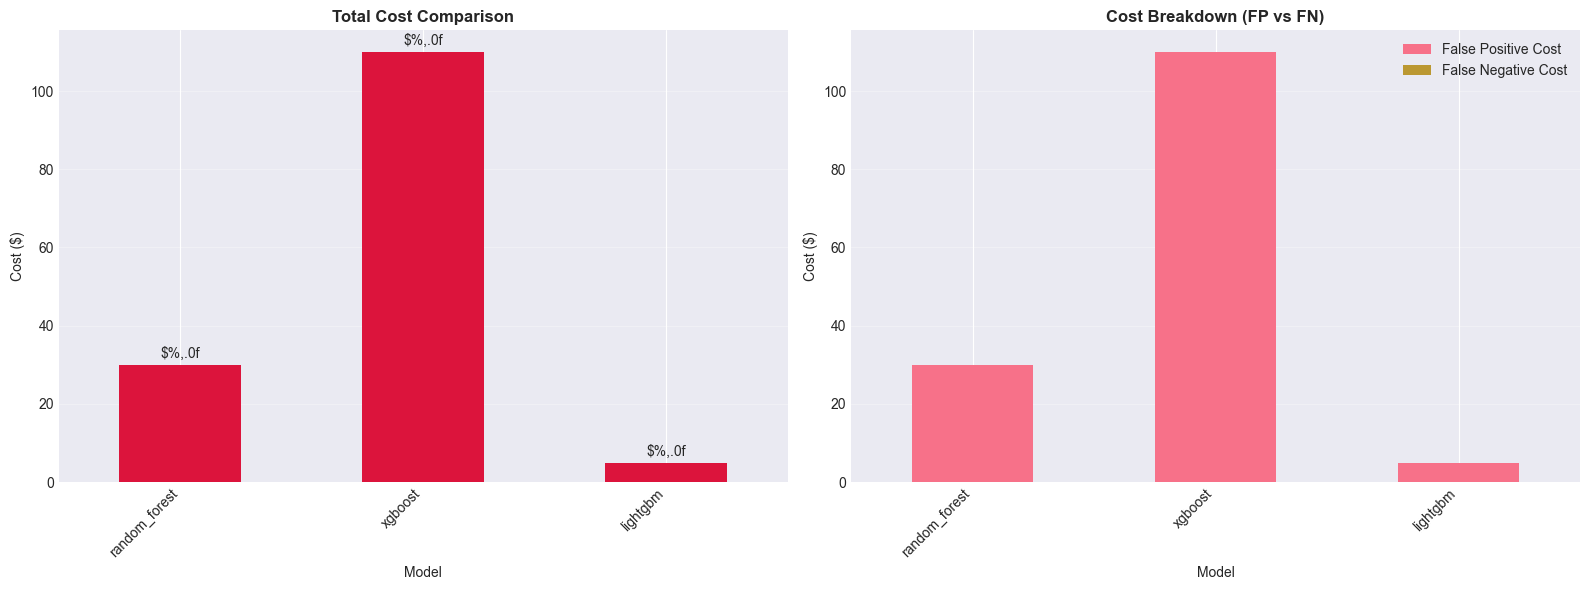

In [7]:
# Cost breakdown visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total cost comparison
ax = axes[0]
df_business['Total Cost ($)'].plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Total Cost Comparison', fontweight='bold')
ax.set_ylabel('Cost ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='$%,.0f', padding=3)

# FP vs FN cost breakdown
ax = axes[1]
df_business[['FP Cost ($)', 'FN Cost ($)']].plot(kind='bar', ax=ax, stacked=True)
ax.set_title('Cost Breakdown (FP vs FN)', fontweight='bold')
ax.set_ylabel('Cost ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(['False Positive Cost', 'False Negative Cost'], loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Threshold Analysis

In [8]:
# Optimal thresholds comparison
threshold_data = []
for model_name, report in reports.items():
    threshold_data.append({
        'Model': model_name,
        'F1-Optimal Threshold': report.get('optimal_threshold_f1', 0.5),
        'Best F1 at Optimal': report.get('best_f1_at_optimal', 0),
        'Cost-Optimal Threshold': report.get('optimal_threshold_cost', 0.5),
        'Min Cost at Optimal': report.get('min_cost_at_optimal', 0),
        'Approve Threshold': report.get('approve_threshold', 0.3),
        'Review/Block Threshold': report.get('block_threshold', 0.7)
    })

df_thresholds = pd.DataFrame(threshold_data).set_index('Model')

print("🎯 THRESHOLD OPTIMIZATION")
print("=" * 80)
display(df_thresholds.style.format({
    'F1-Optimal Threshold': '{:.3f}',
    'Best F1 at Optimal': '{:.4f}',
    'Cost-Optimal Threshold': '{:.3f}',
    'Min Cost at Optimal': '{:,.2f}',
    'Approve Threshold': '{:.2f}',
    'Review/Block Threshold': '{:.2f}'
}))

🎯 THRESHOLD OPTIMIZATION


,F1-Optimal Threshold,Best F1 at Optimal,Cost-Optimal Threshold,Min Cost at Optimal,Approve Threshold,Review/Block Threshold
Model,,,,,,
random_forest,0.998,0.8571,0.646,20.00,0.30,0.00
xgboost,0.999,0.9333,0.939,55.00,0.30,0.00
lightgbm,1.000,1.0000,0.010,5.00,0.30,0.00


## 6. Model Recommendations

Based on the evaluation results, provide recommendations for production deployment.

In [9]:
# Find best model for each metric
print("🏆 BEST MODELS BY METRIC")
print("=" * 80)

metrics_for_best = ['F1-Score', 'Precision', 'Recall', 'ROC-AUC', 'PR-AUC', 'MCC']
for metric in metrics_for_best:
    best_model = df_comparison[metric].idxmax()
    best_value = df_comparison[metric].max()
    print(f"  {metric:12s}: {best_model:15s} ({best_value:.4f})")

print("\n💰 LOWEST COST MODEL")
best_cost_model = df_business['Total Cost ($)'].idxmin()
best_cost_value = df_business['Total Cost ($)'].min()
print(f"  Total Cost: {best_cost_model} (${best_cost_value:,.2f})")

print("\n💡 RECOMMENDATIONS")
print("=" * 80)
print("  1. For HIGHEST F1-SCORE: Use", df_comparison['F1-Score'].idxmax())
print("  2. For LOWEST COST: Use", df_business['Total Cost ($)'].idxmin())
print("  3. For BEST RECALL (catch all fraud): Use", df_comparison['Recall'].idxmax())
print("  4. For BEST PRECISION (avoid false alarms): Use", df_comparison['Precision'].idxmax())
print("\n  🎯 Consider ENSEMBLE of all three models for best results!")

🏆 BEST MODELS BY METRIC
  F1-Score    : lightgbm        (0.9412)
  Precision   : lightgbm        (0.8889)
  Recall      : random_forest   (1.0000)
  ROC-AUC     : lightgbm        (1.0000)
  PR-AUC      : lightgbm        (1.0000)
  MCC         : lightgbm        (0.9428)

💰 LOWEST COST MODEL
  Total Cost: lightgbm ($5.00)

💡 RECOMMENDATIONS
  1. For HIGHEST F1-SCORE: Use lightgbm
  2. For LOWEST COST: Use lightgbm
  3. For BEST RECALL (catch all fraud): Use random_forest
  4. For BEST PRECISION (avoid false alarms): Use lightgbm

  🎯 Consider ENSEMBLE of all three models for best results!


## 7. Export Summary Report

In [10]:
# Save comparison summary
summary_path = REPORTS_DIR / "model_comparison_summary.csv"
df_comparison.to_csv(summary_path)
print(f"✅ Saved comparison summary: {summary_path}")

business_path = REPORTS_DIR / "business_metrics_summary.csv"
df_business.to_csv(business_path)
print(f"✅ Saved business metrics: {business_path}")

print("\n✅ Evaluation analysis complete!")

✅ Saved comparison summary: /Users/bibekgupta/Downloads/projects/finsight-ai/backend/reports/evaluation/model_comparison_summary.csv
✅ Saved business metrics: /Users/bibekgupta/Downloads/projects/finsight-ai/backend/reports/evaluation/business_metrics_summary.csv

✅ Evaluation analysis complete!
